# 데이터 구조 탐색

In [8]:
import pandas as pd
from IPython import display

train = pd.read_csv("../data/raw/train.csv").copy()

head()로 구조 확인
* 특성 개수 11개
* 범주형/숫자형/문자열 등을 확인할 수 있음
    * Pclass, Sex, Embarked, Survived
    * Cabin은 범주형인지 잘 모르겠음 -> value_counts()로 확인해봐야 알 수 있을듯
* 레이블은 Survived

In [9]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


info()로 데이터 결측치 유무 확인 및 데이터 타입 확인
* 행 개수는 총 891개 -> 상당히 적음을 알 수 있음
* Age, Cabin, Embarked에 결측치 존재
* 그러나 테스트셋에는 다른 열에도 결측치가 존재할 가능성을 염두에 둬야한다.

In [10]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


각 범주형 특성에 대해 각 범주타입 개수를 확인한다.
* Pclass -> 3,2,1있음
* Sex -> male, female
* Embarked -> S, C, Q있음

In [26]:
from IPython.display import display
categories = ["Pclass", "Sex", "Embarked"]
cat_train = train[categories].copy()
list = []
for col in categories:
    list.append(cat_train[col].value_counts())

pd.concat(list, axis=1)

,count,count,count
3,491.0,NaN,NaN
1,216.0,NaN,NaN
2,184.0,NaN,NaN
male,NaN,577.0,NaN
female,NaN,314.0,NaN
S,NaN,NaN,644.0
C,NaN,NaN,168.0
Q,NaN,NaN,77.0


In [27]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


* 여기에서 describe로 딱히 알만한건 없음
* 그나마 스케일이 좀 다르다는거? -> 나머지는 히스토그램으로 확인예정
* 특히 AGe, Fare의 평균이 다른 특성에 비해 높다.
* 또한 Fare는 max값을 보면 평균에 비해 상당히 높음 -> 이상치 존재 (이상치는 아니지만 범위가 너무 넓음 근데 75%백분위수를 보면 상당수의 값은 30이하로 되어있음을 알 수 있다.

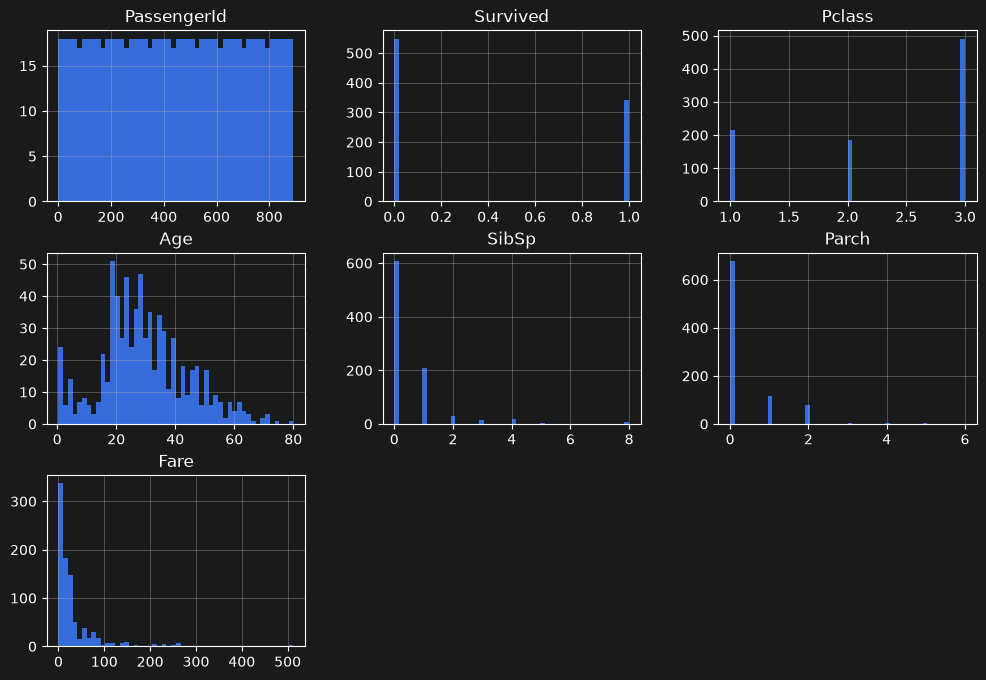

In [28]:
import matplotlib.pyplot as plt
train.hist(bins=50, figsize=(12, 8))
plt.show()

* fare는 오른쪽 꼬리가 상당히 김 (describe에서 확인함)
* Age, Fare의 스케일 조정이 필요 (describe에서 확인함)
* 최댓값, 최솟값이 한정된 특성은 없다.


# 테스트 셋 분리
* test.csv가 존재하지만 이는 실제 제출용 데이터일 뿐 -> 실제 모델에서 사용하는 test셋으로 생각할 필요가 없음
* 어차피 학습 과정에서 k-fold를 사용하기 때문에 -> 검증 세트 자체는 필요가 없음
* 하지만 각 모델별 최종 성능을 측정할 테스트셋을 따로 분리해야 최종 모델을 선택할 수 있음
* 참고로 검증 세트는 하이퍼파라미터를 조정할때 기준점이 된다.
* **계층적 샘플링 적용(Pclass)**

train -> 	모델 파라미터 학습 (fit) (계속 사용)


validation ->   하이퍼파라미터 튜닝, 모델별 비교 (모델을 한번 학습 시킬 때 마다 검증셋을 임시 테스트셋으로 계속 사용)


(검증셋은 우연히 잘못 뽑힐 가능성으로 인해 안정적인 성능 평가를 위해 k-fold사용)


test -> 최종 모델이 결정되면 train + validation으로 전체 재학습 후 -> test셋으로 최종 성능 평가


In [35]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    train, test_size=0.2, stratify=train["Pclass"], random_state=42
)

print(train_set.head())
type(train_set)
train_set.to_csv("../data/processed/01/train.csv", index=False)
test_set.to_csv("../data/processed/01/test.csv", index=False)

     PassengerId  Survived  Pclass  \
820          821         1       1   
439          440         0       2   
821          822         1       3   
403          404         0       3   
343          344         0       2   

                                                  Name     Sex   Age  SibSp  \
820  Hays, Mrs. Charles Melville (Clara Jennings Gr...  female  52.0      1   
439             Kvillner, Mr. Johan Henrik Johannesson    male  31.0      0   
821                                  Lulic, Mr. Nikola    male  27.0      0   
403                     Hakkarainen, Mr. Pekka Pietari    male  28.0      1   
343         Sedgwick, Mr. Charles Frederick Waddington    male  25.0      0   

     Parch            Ticket     Fare Cabin Embarked  
820      1             12749  93.5000   B69        S  
439      0        C.A. 18723  10.5000   NaN        S  
821      0            315098   8.6625   NaN        S  
403      0  STON/O2. 3101279  15.8500   NaN        S  
343      0           

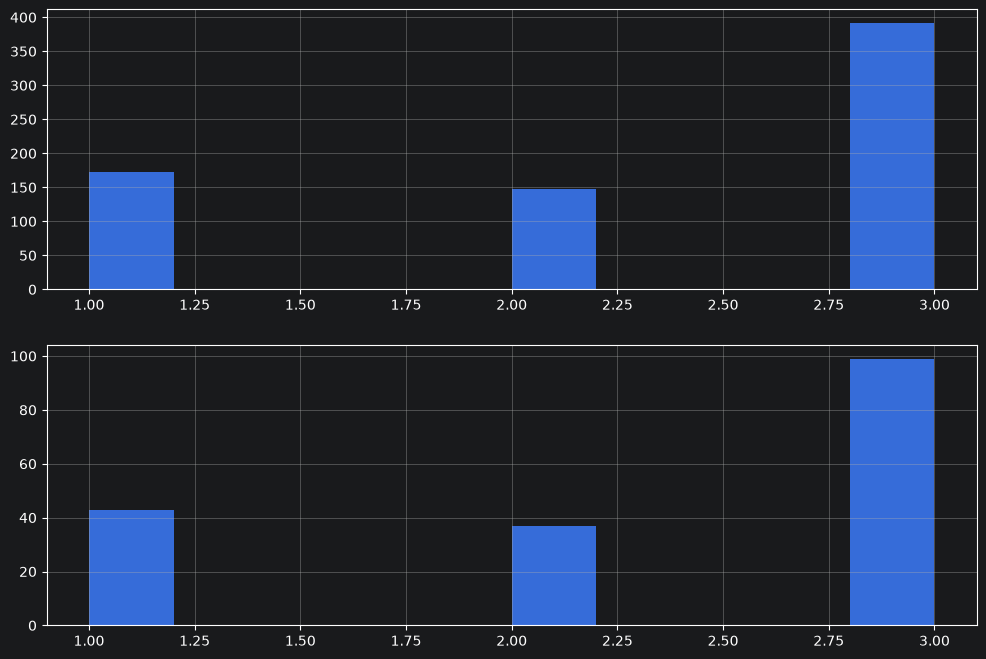

In [39]:
## 잘 분리 됐는지 확인
fig, axes = plt.subplots(nrows=2, figsize=(12, 8))
train_set["Pclass"].hist(ax=axes[0])
test_set["Pclass"].hist(ax=axes[1])
plt.show()

# 데이터 시각화